# tr_diffusion — training-data / model-input visualization

Shows exactly what the **conditional diffusion** denoiser sees during training for one
central frame of `212_Wunderkerze2`:

* the raw dataset item (central `x0` + context: rotation-adjacent `i±1`, same-angle
  temporal `i±P`), in normalized `[-1,1]` and in physical count space;
* the assembled model input `[x_t, corrupted_central, context]` (`in_channels = 2 + 4k`)
  at a diffusion timestep, with the N2V blind-spot corruption, the blind-spot mask and
  the target noise `eps`;
* how `x_t` evolves across timesteps;
* per-channel value **ranges** (histograms + a min/max/mean/std table);
* the "with / without central" conditioning-dropout inputs;
* the optional extra-Poisson-noise regime (input vs lower-noise reference).

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/myhome/sdate')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from diffusers import DDPMScheduler
from sdate.tr_diffusion.data import TimeResolvedFrameDataset
from sdate.tr_diffusion.n2v import blind_spot_corrupt
from sdate.tr_diffusion.geometry import build_context_layout
from sdate.tr_diffusion.profiles import DatasetProfile

# --- Change this one line to point the whole notebook at a different acquisition. ---
PROFILE = 'wunderkerze2'   # or 'asc_thixo', or a profile JSON path
prof = DatasetProfile.load(PROFILE)

MOV = Path(prof.mov_path)
MM  = Path(prof.memmap_path) if prof.memmap_path else None
memmap = MM if (MM is not None and MM.exists()) else None   # falls back to on-the-fly ffmpeg if absent

K = 1  # context radius: in_channels = 2 + 4K
ds = TimeResolvedFrameDataset(
    mov_path=MOV, memmap_path=memmap, k=K,
    frame_start=prof.frame_start, frame_end=prof.frame_end, crop=prof.crop,
    axis_col=prof.rot_axis_col, deg_per_frame=prof.deg_per_frame,
    max_samples=500, seed=0,
)
layout = build_context_layout(K, period_360=prof.period_360)
ctx_names = [t.name for t in layout]
print('profile        :', prof.name, f'({prof.deg_per_frame:.4f} deg/frame, axis col {prof.rot_axis_col})')
print('dataset length :', len(ds))
print('source         :', 'memmap' if memmap else 'ffmpeg')
print('norm_min/max   :', round(ds.norm_min, 2), round(ds.norm_max, 2), '(counts -> [-1,1])')
print('context chans  :', ctx_names)
print('diffusion in_ch:', ds.in_channels_diffusion)

profile        : 212_Wunderkerze2 (1.8014 deg/frame, axis col 269.85)
dataset length : 500
source         : memmap
norm_min/max   : 116.19 714.07 (counts -> [-1,1])
context chans  : ['rot-1', 'rot+1', 'tmp-1', 'tmp+1']
diffusion in_ch: 6


## 1. A raw dataset item

`central` is the target `x0` (the measured, noisy central frame); `context` are the
conditioning neighbours in the fixed channel order. All are normalized to `[-1, 1]`.

In [2]:
SAMPLE = 0
item = ds[SAMPLE]
central = item['central']      # (1, H, W)
context = item['context']      # (4K, H, W)
fi = int(item['frame_index'])
print(f'central frame index: {fi}\n')

def rng(name, t):
    print(f'  {name:14s} shape={tuple(t.shape)}  min={t.min():7.3f} max={t.max():7.3f} '
          f'mean={t.mean():7.3f} std={t.std():6.3f}')

rng('central (x0)', central)
rng('context', context)
for i, n in enumerate(ctx_names):
    rng(n, context[i])

central frame index: 400471



  central (x0)   shape=(1, 128, 512)  min= -1.108 max=  1.256 mean= -0.595 std= 0.499


  context        shape=(4, 128, 512)  min= -1.114 max=  1.269 mean= -0.595 std= 0.502


  rot-1          shape=(128, 512)  min= -1.091 max=  1.269 mean= -0.573 std= 0.513


  rot+1          shape=(128, 512)  min= -1.114 max=  1.256 mean= -0.616 std= 0.482


  tmp-1          shape=(128, 512)  min= -1.091 max=  1.198 mean= -0.583 std= 0.505


  tmp+1          shape=(128, 512)  min= -1.113 max=  1.229 mean= -0.607 std= 0.505


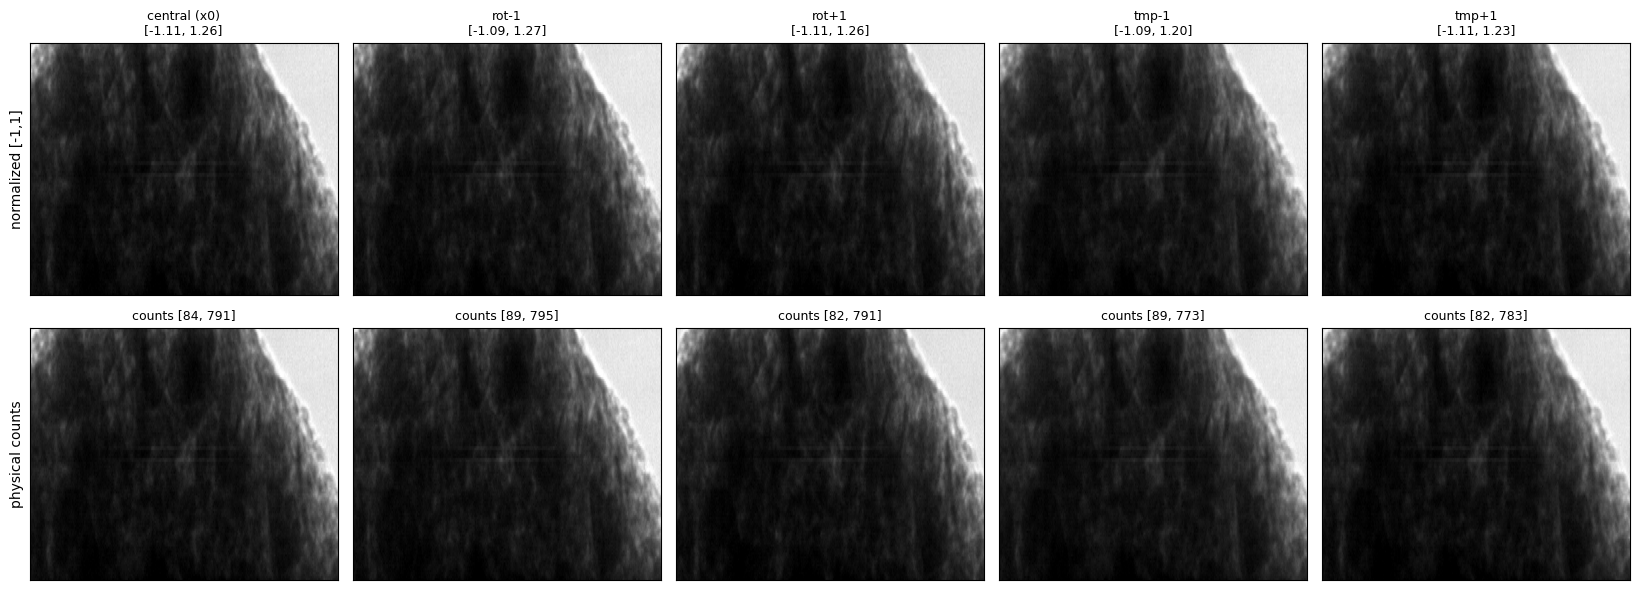

In [3]:
frames = torch.cat([central, context], dim=0)   # (1+4K, H, W)
names = ['central (x0)'] + ctx_names
n = frames.shape[0]

fig, axes = plt.subplots(2, n, figsize=(3.3 * n, 6))
for i in range(n):
    f = frames[i].numpy()
    axes[0, i].imshow(f, cmap='gray', vmin=-1, vmax=1, aspect='auto')
    axes[0, i].set_title(f'{names[i]}\n[{f.min():.2f}, {f.max():.2f}]', fontsize=9)
    c = ds.denormalize(frames[i]).numpy()
    axes[1, i].imshow(c, cmap='gray', vmin=ds.norm_min, vmax=ds.norm_max, aspect='auto')
    axes[1, i].set_title(f'counts [{c.min():.0f}, {c.max():.0f}]', fontsize=9)
    for r in (0, 1):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel('normalized [-1,1]', fontsize=10)
axes[1, 0].set_ylabel('physical counts', fontsize=10)
plt.tight_layout(); plt.show()

## 2. What the diffusion model actually sees

The training input is `torch.cat([x_t, corrupted_central, context], dim=1)`, shape
`(B, 2 + 4K, H, W)`. `x_t` is `x0` noised to a random timestep by the DDPM scheduler;
`corrupted_central` is the Noise2Void blind-spot corruption of `x0` (the model never sees
`x0` cleanly). The model predicts the added noise `eps`, and the loss is taken **only at
the blind-spot pixels** (when the central frame is present).

In [4]:
scheduler = DDPMScheduler(num_train_timesteps=1000)
torch.manual_seed(0)

x0  = central.unsqueeze(0)     # (1, 1, H, W)
ctx = context.unsqueeze(0)     # (1, 4K, H, W)
t   = torch.tensor([500])      # a mid-schedule timestep for display
noise = torch.randn_like(x0)
x_t = scheduler.add_noise(x0, noise, t)
corrupted, mask = blind_spot_corrupt(x0, ratio=0.02, window=5)

model_input = torch.cat([x_t, corrupted, ctx], dim=1)   # (1, 2+4K, H, W)
in_names = ['x_t (noised x0)', 'corrupted central'] + ctx_names
print('model_input shape :', tuple(model_input.shape), ' (timestep t =', int(t), ')')
print('overall input range: [%.3f, %.3f]' % (model_input.min(), model_input.max()))

model_input shape : (1, 6, 128, 512)  (timestep t = 500 )
overall input range: [-4.281, 4.205]


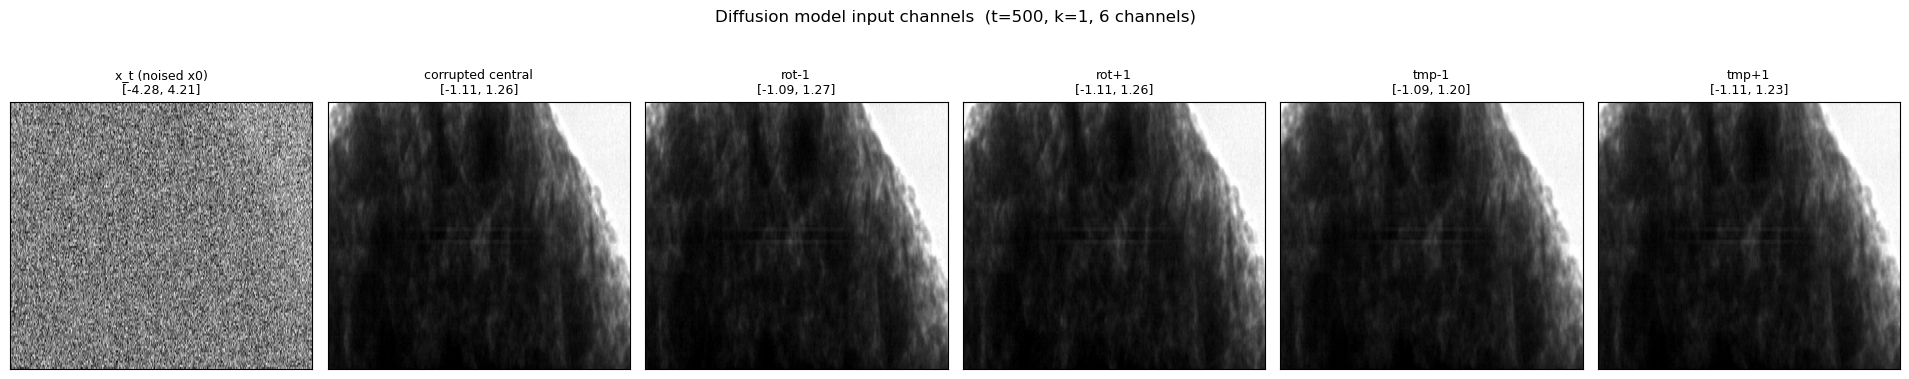

In [5]:
inp = model_input[0]
n = inp.shape[0]
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.6))
for i in range(n):
    f = inp[i].numpy()
    lo, hi = np.percentile(f, [1, 99])
    axes[i].imshow(f, cmap='gray', vmin=lo, vmax=hi, aspect='auto')
    axes[i].set_title(f'{in_names[i]}\n[{f.min():.2f}, {f.max():.2f}]', fontsize=9)
    axes[i].set_xticks([]); axes[i].set_yticks([])
fig.suptitle(f'Diffusion model input channels  (t={int(t)}, k={K}, {n} channels)', y=1.04)
plt.tight_layout(); plt.show()

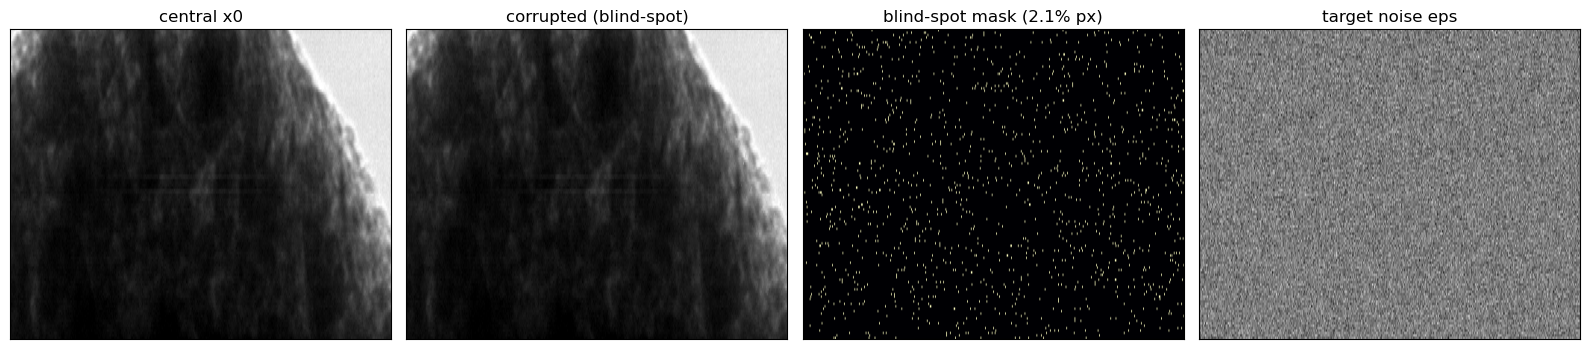

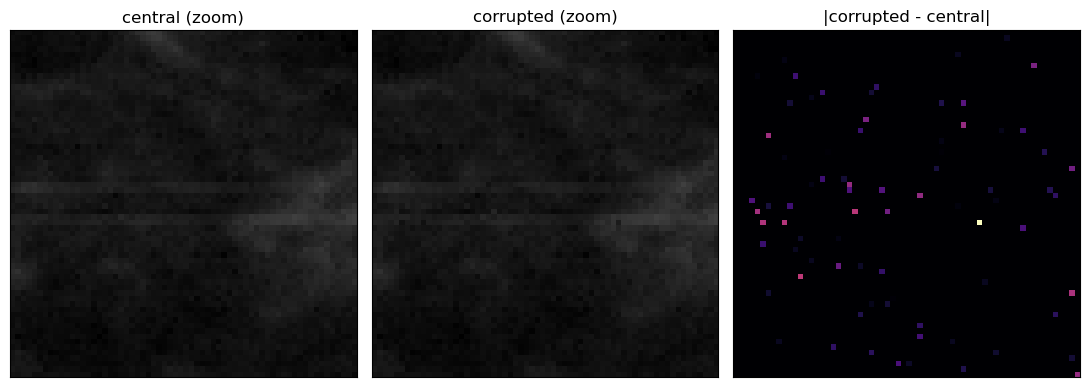

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
axes[0].imshow(central[0], cmap='gray', vmin=-1, vmax=1, aspect='auto'); axes[0].set_title('central x0')
axes[1].imshow(corrupted[0, 0], cmap='gray', vmin=-1, vmax=1, aspect='auto'); axes[1].set_title('corrupted (blind-spot)')
axes[2].imshow(mask[0, 0].float(), cmap='magma', aspect='auto'); axes[2].set_title(f'blind-spot mask ({mask.float().mean()*100:.1f}% px)')
axes[3].imshow(noise[0, 0], cmap='gray', aspect='auto'); axes[3].set_title('target noise eps')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

# Zoom to see individual replaced pixels.
sl = (slice(32, 96), slice(200, 264))
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
axes[0].imshow(central[0][sl], cmap='gray', vmin=-1, vmax=1); axes[0].set_title('central (zoom)')
axes[1].imshow(corrupted[0, 0][sl], cmap='gray', vmin=-1, vmax=1); axes[1].set_title('corrupted (zoom)')
axes[2].imshow((corrupted[0, 0] - central[0]).abs()[sl], cmap='magma'); axes[2].set_title('|corrupted - central|')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. `x_t` across diffusion timesteps

Same `x0` and noise, different timestep. Early `t` is close to the (normalized) frame;
late `t` approaches standard Gaussian noise — note the range widening well beyond `[-1,1]`.

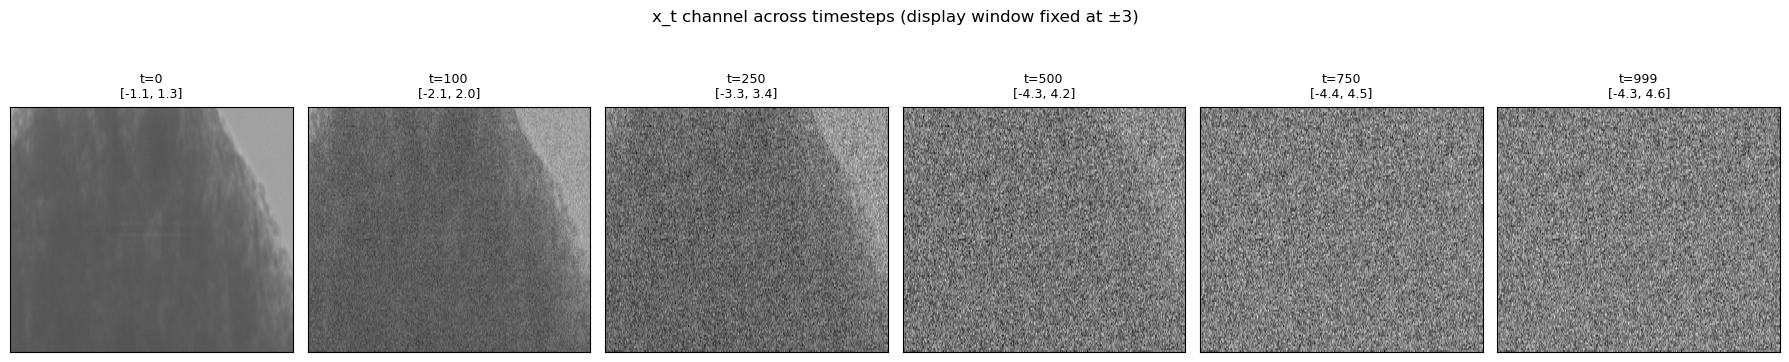

In [7]:
ts = [0, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(ts), figsize=(3 * len(ts), 3.4))
for ax, tv in zip(axes, ts):
    xt = scheduler.add_noise(x0, noise, torch.tensor([tv]))[0, 0].numpy()
    ax.imshow(xt, cmap='gray', vmin=-3, vmax=3, aspect='auto')
    ax.set_title(f't={tv}\n[{xt.min():.1f}, {xt.max():.1f}]', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('x_t channel across timesteps (display window fixed at ±3)', y=1.05)
plt.tight_layout(); plt.show()

## 4. Value ranges of the input channels

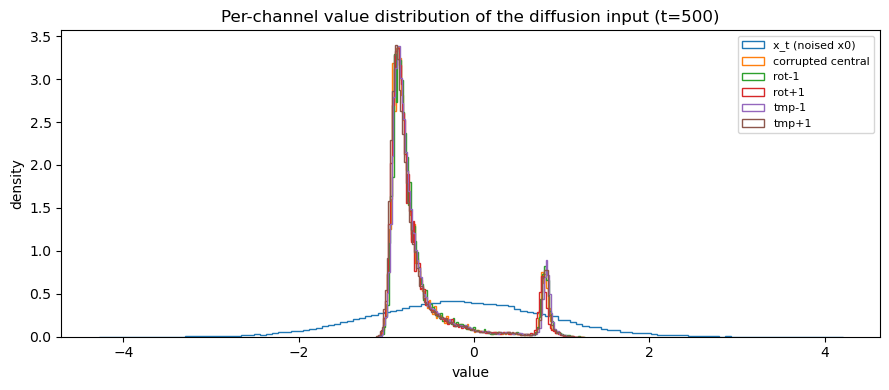

channel                min     max    mean     std
--------------------------------------------------
x_t (noised x0)     -4.281   4.205  -0.169   0.969
corrupted central   -1.108   1.256  -0.595   0.498


rot-1               -1.091   1.269  -0.573   0.513
rot+1               -1.114   1.256  -0.616   0.482


tmp-1               -1.091   1.198  -0.583   0.505
tmp+1               -1.113   1.229  -0.607   0.505


In [8]:
inp = model_input[0]
fig, ax = plt.subplots(figsize=(9, 4))
for i in range(inp.shape[0]):
    ax.hist(inp[i].numpy().ravel(), bins=120, histtype='step', density=True, label=in_names[i])
ax.set_title(f'Per-channel value distribution of the diffusion input (t={int(t)})')
ax.set_xlabel('value'); ax.set_ylabel('density'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'{"channel":18s} {"min":>7s} {"max":>7s} {"mean":>7s} {"std":>7s}')
print('-' * 50)
for i, nme in enumerate(in_names):
    f = inp[i]
    print(f'{nme:18s} {f.min():7.3f} {f.max():7.3f} {f.mean():7.3f} {f.std():7.3f}')

## 5. Conditioning dropout — "with / without central"

With probability `1 - conditioning_probability` the corrupted-central channel is zeroed
and `class_label = 0`; those samples train the pure conditional-on-neighbours objective
(full-frame loss). Otherwise the corrupted central is present (`class_label = 1`) and the
loss is taken only at the blind-spot pixels.

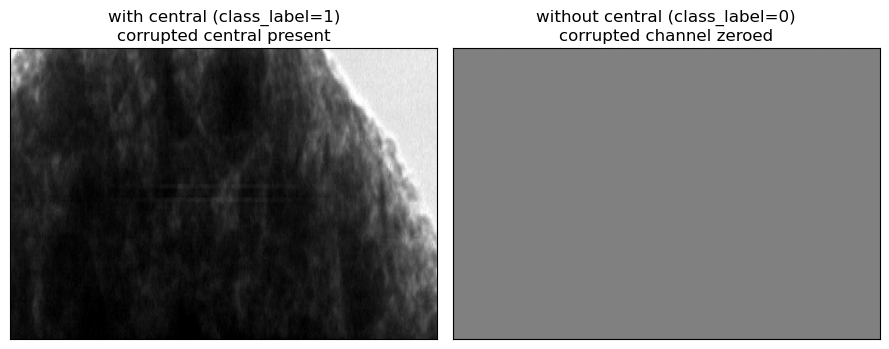

In [9]:
corrupted_dropped = torch.zeros_like(corrupted)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].imshow(corrupted[0, 0], cmap='gray', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('with central (class_label=1)\ncorrupted central present')
axes[1].imshow(corrupted_dropped[0, 0], cmap='gray', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title('without central (class_label=0)\ncorrupted channel zeroed')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. Extra-Poisson-noise regime (evaluation)

`extra_noise_dose` injects additional Poisson noise into every frame; the original
measured central is kept as a lower-noise **reference** (pseudo-GT for metrics).

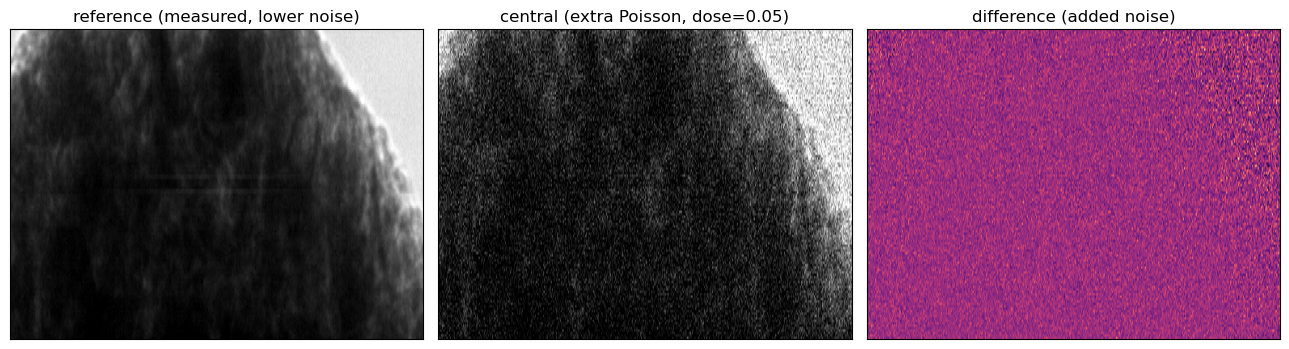

reference range [-1.11, 1.26] std 0.482
noisy central   [-1.39, 2.22] std 0.532


In [10]:
ds_noisy = TimeResolvedFrameDataset(
    mov_path=MOV, memmap_path=memmap, k=K,
    frame_start=prof.frame_start, frame_end=prof.frame_end, crop=prof.crop,
    axis_col=prof.rot_axis_col, deg_per_frame=prof.deg_per_frame,
    extra_noise_dose=0.05, max_samples=50,
    norm_range=(ds.norm_min, ds.norm_max),
)
itn = ds_noisy[0]
ref, cen = itn['reference'][0], itn['central'][0]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].imshow(ref, cmap='gray', vmin=-1, vmax=1, aspect='auto'); axes[0].set_title('reference (measured, lower noise)')
axes[1].imshow(cen, cmap='gray', vmin=-1, vmax=1, aspect='auto'); axes[1].set_title('central (extra Poisson, dose=0.05)')
axes[2].imshow((cen - ref), cmap='magma', aspect='auto'); axes[2].set_title('difference (added noise)')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print('reference range [%.2f, %.2f] std %.3f' % (ref.min(), ref.max(), ref.std()))
print('noisy central   [%.2f, %.2f] std %.3f' % (cen.min(), cen.max(), cen.std()))